In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, log_loss
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import matplotlib as mpl

import mlflow 
import pandas as pd
import numpy as np

import argparse


import xgboost as xgb
import matplotlib as mpl
from ydata_profiling import ProfileReport

import mlflow
import mlflow.xgboost

import time
from sklearn.metrics import roc_auc_score
# hyperparameter tuning
from hyperopt import fmin, tpe, hp, SparkTrials, STATUS_OK
from hyperopt.pyll import scope



from constants import  *

ModuleNotFoundError: No module named 'importlib_metadata'

In [2]:
def plot_one_prediction(df_pred,label="",xl=[-10,10],yl=[-10,10]):
    plt.rc('font', size=8)
    sel=(df_pred.x<xl[1]) & (df_pred.x>xl[0])&(df_pred.y<yl[1]) & (df_pred.y>yl[0])  
    xx=df_pred[sel]["x"]
    yy=df_pred[sel]["y"]
    H, xedges, yedges = np.histogram2d(df_pred[sel]["x"],df_pred[sel]["y"], bins=500)
    H = H.T
    plt.pcolormesh(xedges, yedges, H, cmap=plt.cm.jet, norm=mpl.colors.LogNorm())
    #xl=[df_pred[sel]["x"].min(),df_pred[sel]["x"].max()]
    #yl=[df_pred[sel]["y"].min(),df_pred[sel]["y"].max()]

    plt.xlim(xl[0], xl[1])
    plt.ylim(yl[0], yl[1])
    score=round(r2_score(xx, yy,multioutput='variance_weighted'),2)
    plt.title(label+f"score={score} Np="+str(len(df_pred[sel]["x"])))
    plt.xlabel("y")
    plt.ylabel("$\^y$")
    plt.plot(xl,yl,color="black")
    plt.colorbar()
    fig_file=f"{label}.png"
    plt.savefig(fig_file)
    plt.show()
    plt.close()
    return fig_file

def eval_metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)
    return (rmse, mae, r2)


# TODO optimize for DASK
def fetch_data(fpath="data/combined_trainingset2_with_xp_norm.ONE.parq"):
    #df=pd.read_csv(fpath).set_index("source_id")
    df=pd.read_parquet(fpath)
    return df

def okay_condition(trainingset, label="met50"):
    """
    Return a condition that defines an acceptable subset for training
    FA: nur metallicities mit guten uncertainties
    FA: für alle training data ausser VMP: ein [M/H] cut (wegen der grid boundary)
    FA: es heisst: keine white dwarfs
    """
    if label=="met50":
        return (trainingset["survey"] != b'WDs EDR3') & \
               ((trainingset["survey"] == b'VMPs') | (trainingset["met50"] > -2.)) & \
               (trainingset["met84"] - trainingset["met16"] < 0.5) & \
               (np.isfinite(trainingset["bp_coefficients_1"]))
    else:
        return (np.isfinite(trainingset["bp_coefficients_1"]))
    
def prepare_data(trainingset,label, random_state=0, frac=0.1, fillvalue=-9.99, 
                        cachepath="cache"):
    """
    Get the desired training and test data (given one label)
    """
    # Read the file
    # TODO make cache for each label 
    #trainingset = dd.read_parquet(trainfilepath)
    # Add the label if necessary:
    if label=='logdist50':
        trainingset['logdist50'] = np.log10(trainingset['dist50'])
    elif label=='logteff50':
        trainingset['logteff50'] = np.log10(trainingset['teff50'])
    else:
        pass
    # Determine the "okay" part of the training set
    ok  = okay_condition(trainingset, label)
    # Cut out the desired part of the training set and repartition
    # Currently no DASK
    trainingset = trainingset[ok][features + [label]].sample(frac=frac).fillna(fillvalue)#.persist()#repartition(npartitions=256)
    
    ## Make weights
    trainlabels   = trainingset[label]
    ## First the histogram
    hist, bin_edges = np.histogram(trainlabels, bins=30)
    bin_centres     = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    ## Then convert this to a KDE
    kde                    = gaussian_kde(bin_centres, weights=hist, bw_method=bin_edges[1]-bin_edges[0])
    ## Then compute the weights
    trainingset["weights"] = 1.0/kde.evaluate(trainingset[label]) #trainingset[label].map_partitions(lambda x: 1. / kde.evaluate(x))
    
    #weights = trainingset["weights"]
  

    # Split dataframe into input and output columns
    X   = trainingset.drop(columns=[label])#.to_dask_array(lengths=True)
    #y   = trainingset[label]#.to_dask_array(lengths=True)
    # Splitting into train and test
    #train_X, test_X, train_y, test_y = train_test_split(X, y,
    #                  test_size = 0.2, random_state = 123)
    # Compute weights

   
    for icol in trainingset.columns:
        if trainingset[icol].dtype != np.dtype('float32'):
            print(icol,trainingset[icol].dtype)
            trainingset[icol]=trainingset[icol].astype("float32")
    
    return trainingset#train_X, test_X, train_y, test_y


In [3]:
ii=4
label = pred_vec[ii]
rawdata = fetch_data()
data=prepare_data(rawdata,label,random_state=42,frac=1.0)
print(len(data))
print(f"{round(data.memory_usage(index=True).sum()/1024/1024)}MB")
#del(rawdata)
print(f"{round(rawdata.memory_usage(index=True).sum()/1024/1024)}MB")
len(rawdata), len(rawdata[rawdata["survey"] == b'VMPs'])

C:\Users\arm2a\AppData\Local\Temp\ipykernel_19428\3267041215.py:84: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  trainingset["weights"] = 1.0/kde.evaluate(trainingset[label]) #trainingset[label].map_partitions(lambda x: 1. / kde.evaluate(x))


bp_coefficients_52 object
rp_coefficients_52 object
j_m float64
h_m float64
ks_m float64
w1mpro float64
w2mpro float64
w3mpro float64
w4mpro float64
vmag float64
bmag float64
g_mag float64
r_mag float64
i_mag float64
g_mean_psf_mag float64
r_mean_psf_mag float64
i_mean_psf_mag float64
z_mean_psf_mag float64
y_mean_psf_mag float64
u_psf float64
v_psf float64
g_psf float64
r_psf float64
i_psf float64
z_psf float64
weights float64
6006587
3231MB
4889MB


(6117438, 3337)

In [4]:
del(rawdata)

In [6]:
# RUN:
# cd  D:\Users\arm2arm\Projects\jupyter\MLUtils\mlflow 
# mlflow ui
def train_sh23_model(data,params,label="target",mlflow_experiment_id=1):
    
    train, test = train_test_split(data)

    # The predicted column is "quality" which is a scalar from [3, 9]
    weights=train["weights"]
    if label != "met50":
        weights=train["weights"]*0.0+1
        
    X_train = train.drop([label,"weights"], axis=1)
    X_test = test.drop([label,"weights"], axis=1)
    y_train = train[[label]]
    y_test = test[[label]]
    
    # enable auto logging
    mlflow.set_tracking_uri("http://localhost:5000")
    mlflow.xgboost.autolog()
    dtrain = xgb.DMatrix(X_train, label=y_train, weight=weights)
    dtest =  xgb.DMatrix(X_test, label=y_test)
   
   
    #xgbRegressor = xgb.XGBRegressor(
    #    **optimized_params
    #    )
    xgb.set_config(verbosity=1)
    with mlflow.start_run(experiment_id=mlflow_experiment_id):
       
        model = xgb.train(params, dtrain, num_boost_round=1000,verbose_eval=True,early_stopping_rounds=10,evals=[(dtrain, "train")])
        # Start prediction
        y_pred = model.predict(dtest)
        df_pred=pd.DataFrame({"x":y_test[label].values,"y":y_pred})
        dflims=df_pred.describe().T
        print(len(df_pred))
        img_fname=plot_one_prediction(df_pred,label)#,[dflims.loc["x"]["25%"]*0.2,dflims.loc["x"]["75%"]*1.8],[dflims.loc["y"]["25%"]*0.2,dflims.loc["y"]["75%"]*1.8])
        mlflow.log_artifact(img_fname)
        (rmse, mae, r2) = eval_metrics(y_test, y_pred)
            
        y_pred = model.predict(dtrain)
        df_pred=pd.DataFrame({"x":y_train[label].values,"y":y_pred})
        dflims=df_pred.describe().T
        img_fname=plot_one_prediction(df_pred,label+"_train_")#,[dflims.loc["x"]["25%"]*0.2,dflims.loc["x"]["75%"]*1.8],[dflims.loc["y"]["25%"]*0.2,dflims.loc["y"]["75%"]*1.8])
        mlflow.log_artifact(img_fname)
    return model,X_train,X_test,y_train,y_test


In [10]:
learning_rate=[0.1,0.05,0.005]
max_depth=[6,8,12]
min_child_weight=[4,6,8]

params={
"tree_method": "gpu_hist",
#'tree_method':'hist',
"random_state":42,
"learning_rate":0.05,
"max_depth":8,
"min_child_weight":4,
#"n_estimators":2000,
#"eval_metric":"rmsle",
"objective":"reg:squarederror",
"eval_metric":["mae","rmse"],
#"objective":"reg:pseudohubererror",
#"huber_slope":1.0,
"subsample":0.8,
#"eta":0.5
#'num_boost_round':100
#'verbose_eval': False
}

params={"tree_method": "gpu_hist",
        'learning_rate': 0.09, 
        'max_depth': 7, 
        'min_child_weight': 79.0, 
        'subsample': 0.8,
        "objective":"reg:squarederror",
        "eval_metric":["mae","rmse"],
       }

label = pred_vec[ii]
mlflow_experiment_id=654086611108235667
print(f"total datasets:{len(data)}")

total datasets:6006587


[0]	train-mae:2.73713	train-rmse:3.19362
[1]	train-mae:2.50383	train-rmse:2.92931
[2]	train-mae:2.30173	train-rmse:2.70651
[3]	train-mae:2.10343	train-rmse:2.47669
[4]	train-mae:1.92965	train-rmse:2.27998
[5]	train-mae:1.76798	train-rmse:2.09219
[6]	train-mae:1.61540	train-rmse:1.91283
[7]	train-mae:1.48104	train-rmse:1.75536
[8]	train-mae:1.36099	train-rmse:1.61524
[9]	train-mae:1.24911	train-rmse:1.48288
[10]	train-mae:1.15877	train-rmse:1.38113
[11]	train-mae:1.06703	train-rmse:1.27195
[12]	train-mae:0.98409	train-rmse:1.17324
[13]	train-mae:0.91055	train-rmse:1.08844
[14]	train-mae:0.84382	train-rmse:1.00836
[15]	train-mae:0.78429	train-rmse:0.93695
[16]	train-mae:0.72619	train-rmse:0.86644
[17]	train-mae:0.67683	train-rmse:0.80902
[18]	train-mae:0.62941	train-rmse:0.75055
[19]	train-mae:0.58712	train-rmse:0.69915
[20]	train-mae:0.54723	train-rmse:0.64980
[21]	train-mae:0.51174	train-rmse:0.60643
[22]	train-mae:0.47966	train-rmse:0.56768
[23]	train-mae:0.45069	train-rmse:0.53277
[2

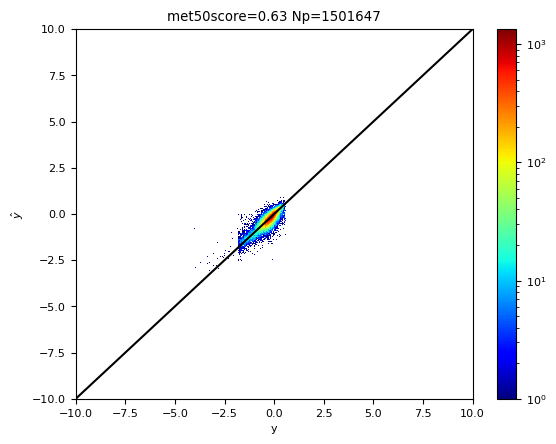

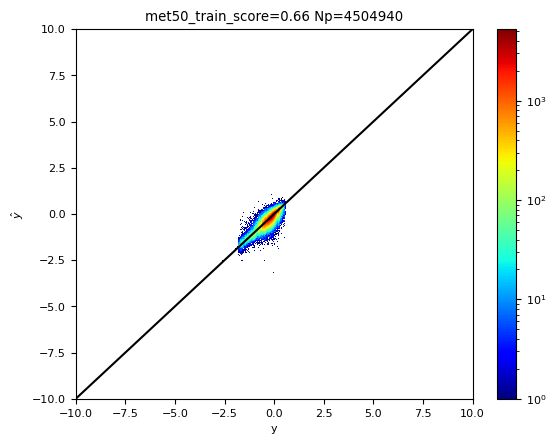

In [11]:
model,X_train,X_test,y_train,y_test=train_sh23_model(data,params,label, mlflow_experiment_id)

In [8]:
train, test = train_test_split(data)

In [9]:
len(train),len(test)

(450494, 150165)

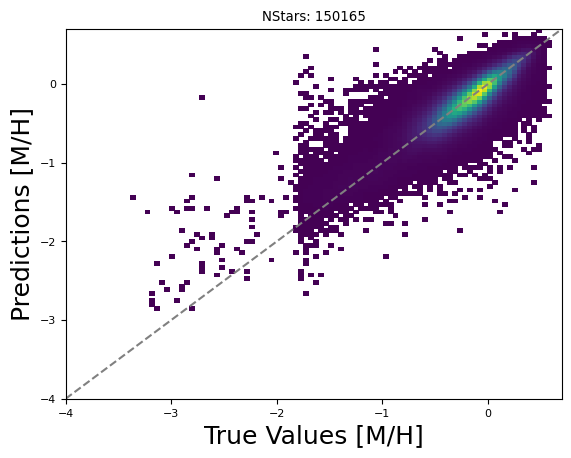

In [10]:
pltlabel = "M/H"
dtest =  xgb.DMatrix(X_test, label=y_test)
xx = y_test.values.flatten()#.compute()
yy = model.predict(dtest).flatten()
lims = [-4, 0.7]
H,X,Y=np.histogram2d(xx, yy, bins=100,range=[lims, lims])
XX,YY=np.meshgrid(X,Y)
from scipy import ndimage
ax = plt.subplot(111)
Hg = ndimage.gaussian_filter(H,sigma=(0.7,0.7),order=0)
Hg[H<1] = np.NaN
image = ax.pcolor(XX, YY,Hg.T) #, cmap=cmaps[ii],norm=LogNorm(vmax=450),alpha=.5)
plt.xlabel('True Values ['+ pltlabel + ']', fontsize=18)
plt.ylabel('Predictions ['+ pltlabel + ']', fontsize=18)
plt.xlim(lims)
plt.ylim(lims)
plt.title(f"NStars: {len(xx)}")
plt.plot(lims, lims, c="grey", ls="dashed")

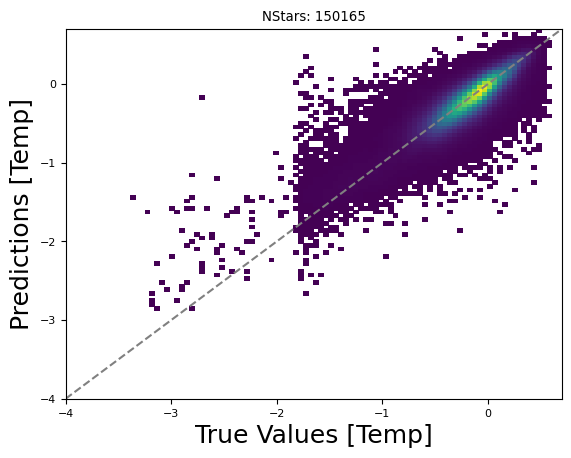

In [11]:
pltlabel = "Temp"
dtest =  xgb.DMatrix(X_test, label=y_test)
xx = y_test.values.flatten()#.compute()
yy = model.predict(dtest).flatten()
lims = [-4, 0.7]
H,X,Y=np.histogram2d(xx, yy, bins=100,range=[lims, lims])
XX,YY=np.meshgrid(X,Y)
from scipy import ndimage
ax = plt.subplot(111)
Hg = ndimage.gaussian_filter(H,sigma=(0.7,0.7),order=0)
Hg[H<1] = np.NaN
image = ax.pcolor(XX, YY,Hg.T) #, cmap=cmaps[ii],norm=LogNorm(vmax=450),alpha=.5)
plt.xlabel('True Values ['+ pltlabel + ']', fontsize=18)
plt.ylabel('Predictions ['+ pltlabel + ']', fontsize=18)
plt.xlim(lims)
plt.ylim(lims)
plt.title(f"NStars: {len(xx)}")
plt.plot(lims, lims, c="grey", ls="dashed")

150165
N Low Met=429
Should be N Low Met=912


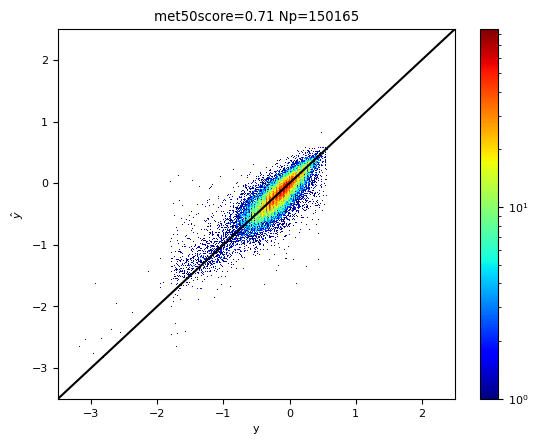

In [12]:
dtest =  xgb.DMatrix(X_test, label=y_test)
y_pred = model.predict(dtest)
df_pred=pd.DataFrame({"x":y_test[label].values,"y":y_pred})
dflims=df_pred.describe().T
print(len(df_pred))
print(f"N Low Met={len(df_pred[df_pred.y<-1.5])}")
print(f"Should be N Low Met={len(df_pred[df_pred.x<-1.5])}")
img_fname=plot_one_prediction(df_pred,label,[-3.5,2.5],[-3.5,2.5])

150165


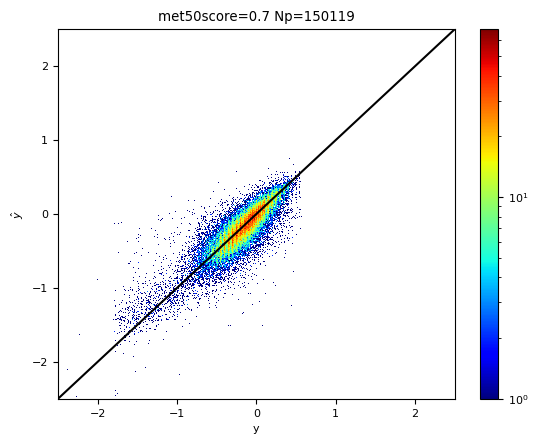

In [13]:
dtest =  xgb.DMatrix(X_test, label=y_test)
y_pred = model.predict(dtest)
df_pred=pd.DataFrame({"x":y_test[label].values,"y":y_pred})
dflims=df_pred.describe().T
print(len(df_pred))
img_fname=plot_one_prediction(df_pred,label,[-2.5,2.5],[-2.5,2.5])

In [14]:
import umap

In [15]:
train, test = train_test_split(data)

# The predicted column is "quality" which is a scalar from [3, 9]
X_train = train.drop([label], axis=1)
X_test = test.drop([label], axis=1)
y_train = train[[label]]
y_test = test[[label]]
    

<AxesSubplot: >

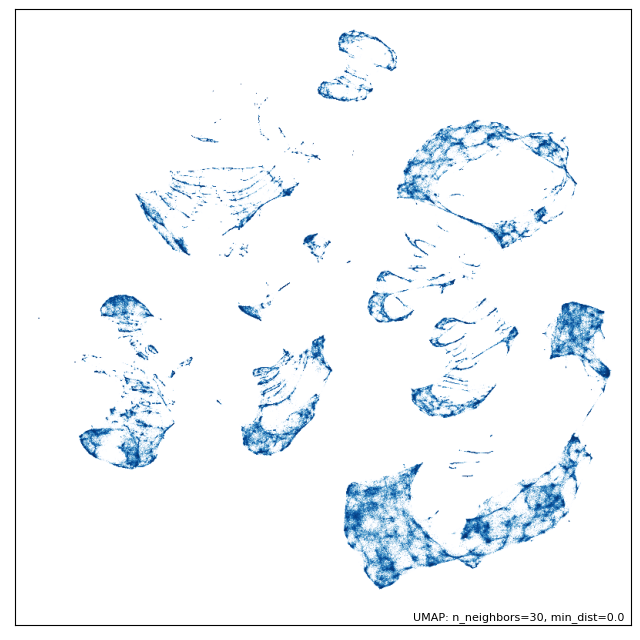

In [16]:
import umap.plot

mapper = umap.UMAP(n_neighbors=30,target_metric="L2",
                              min_dist=0.0,
                              n_components=2,
                              random_state=42).fit(X_train)#[X_test.columns[4:50]])
umap.plot.points(mapper)

In [17]:
import hyperopt
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import xgboost as xgb
train, test = train_test_split(data)

# The predicted column is "quality" which is a scalar from [3, 9]
if True:
    X_train = train.drop([label,"weights"], axis=1)
    X_test = test.drop([label,"weights"], axis=1)
    y_train = train[[label]]
    y_test = test[[label]]

In [18]:
import hyperopt as hp
from hyperopt import Trials,fmin,STATUS_OK
import xgboost as xgb


### Step 1 : defining the objective function
def objective(params, n_folds=3):

# Converting pandas dataframe into xgboost format
    d_train = xgb.DMatrix(X_train, y_train)    

# Running cross validation on your xgboost model
    cv_results = xgb.cv(params, d_train, nfold = n_folds, num_boost_round = 500, 
                        early_stopping_rounds = 25, metrics = 'rmse', seed = 42)
# returns the loss on validation set
    loss = min(cv_results['test-rmse-mean'])
    return loss


### step 2 : defining the search space
xgb_space = {
    'tree_method':"gpu_hist",
    "learning_rate":hp.hp.quniform('learning_rate',0.01,0.6,0.02),
#    max_depth : maximum depth allowed for every tree
# hp.choice.choice will select 1 value from the given list
    'max_depth':hp.hp.choice('max_depth', np.arange(6, 14,1, dtype=int)),
#    subsample : maximum allowed rows for every tree
    'subsample':hp.hp.quniform('subsample',0.5,1.0,0.05),
#    colsample_bytree : maximum allowed features for every tree
# hp.hp.quniform returns a float between a given range
#    'colsample_bytree':hp.hp.quniform('colsample_bytree',0.5,1.0,0.05),
#    min_child-weight : minimum number of instances required in each node
    'min_child_weight':hp.hp.quniform('min_child_weight', 1, 100,1),
    "objective":"reg:squarederror",
    "eval_metric":["mae","rmse"],
#    reg_alpha : L1 regularisation term on weights
#    'reg_alpha': hp.hp.uniform('reg_alpha', 0.0, 1.0),
#    reg_lambda : L2 regularisation term on weights
#    'reg_lambda': hp.hp.uniform('reg_lambda', 0.0, 1.0)
}
    
    
### step 3 : storing the results of every iteration    
bayes_trials = Trials()
MAX_EVALS = 20

# Optimize
best = fmin(fn = objective, space = xgb_space, algo = hp.tpe.suggest, 
max_evals = MAX_EVALS, trials = bayes_trials)

### best will the return the the best hyperparameter set
print(best)

100%|████████████████████████████████████████████████| 20/20 [05:48<00:00, 17.43s/trial, best loss: 0.1481124871050901]
{'learning_rate': 0.08, 'max_depth': 7, 'min_child_weight': 79.0, 'subsample': 0.65}


In [5]:
train, test = train_test_split(data)

# The predicted column is "quality" which is a scalar from [3, 9]
if True:
    X_train = train.drop([label,"weights"], axis=1)
    X_test = test.drop([label,"weights"], axis=1)
    y_train = train[[label]]
    y_test = test[[label]]
    

In [15]:
import mlflow
# enable auto logging
mlflow.set_tracking_uri("http://localhost:5000")
logged_model = 'runs:/dcdf7dd33d1a4405afd718f52ce9a68e/model'

# Load model as a PyFuncModel.
loaded_model = mlflow.pyfunc.load_model(logged_model)

y_pred=loaded_model.predict(pd.DataFrame(X_test))


d:\ProgramData\Miniconda3\envs\st23\lib\site-packages\mlflow\models\utils.py:453: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_pf_input[x] = _enforce_mlflow_datatype(x, pf_input[x], input_types[i])
d:\ProgramData\Miniconda3\envs\st23\lib\site-packages\mlflow\models\utils.py:453: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_pf_input[x] = _enforce_mlflow_datatype(x, pf_input[x], input_types[i])
d:\ProgramData\Miniconda3\envs\st23\lib\site-packages\mlflow\models\utils.py:453: PerformanceWarning: DataFrame is highly fragme

1501647


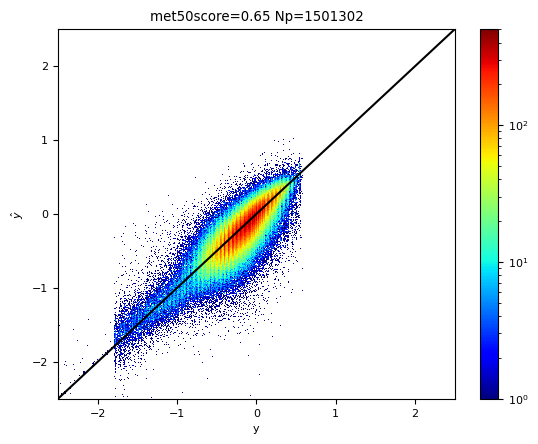

In [16]:
df_pred=pd.DataFrame({"x":y_test[label].values,"y":y_pred})
dflims=df_pred.describe().T
print(len(df_pred))
img_fname=plot_one_prediction(df_pred,label,[-2.5,2.5],[-2.5,2.5])